# 06 · 2026 Scenarios

Notebook 6 of 6 · **Eastern Cape Municipal Electoral Dynamics**

**Question.** *What do the validated historical patterns imply for municipal turnout and party support in the 4 November 2026 Local Government Elections, and how sensitive are those implications to assumptions?*

| | |
|---|---|
| **Inputs** | Master panel (Phase 3); selected methods and error scales (Phases 4–5); optional 2026 registration snapshot |
| **Outputs** | `data/processed/scenarios/phase6/*.csv`, figures in `reports/figures/phase6/` |
| **Code** | `src/models/scenarios.py` (the same functions power the dashboard's scenario explorer) |

**These are model-based scenarios, not forecasts of what will happen.** Each scenario combines:

1. a **validated municipal pattern** (relative turnout position; party composition under the selected methods), and
2. a **stated assumption** the data cannot validate (the provincial turnout level; optional uniform party swings).

**At a glance**
- Three provincial turnout levels are shown: a **repeat of 2021** (about 48%), **partial recovery** (about 52%) and a **return to 2016** participation (about 56%). Each municipality keeps its 2021 position relative to the province, with a ±3.8-point band from historical errors.
- Under the validated party methods, the ANC has the largest share in 31 municipalities and the DA in 2. **Nelson Mandela Bay is too close to call** (gap about 0.5 points against a typical error of about 2.7 points).
- A uniform swing of only about 3.6 points from the leader to the runner-up would change the largest party in Dr Beyers Naude; Nelson Mandela Bay changes with a swing of under 0.5 points.

In [1]:
# Setup: locate the repository root so this notebook runs from any working folder,
# then import the shared project code in src/ (the single source of truth for logic).
import sys, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import config as C
from src.visualization.style import apply_style, subtitle, save, choropleth, map_colorbar, source_note, SEQ_CMAP, DIV_CMAP

apply_style()
C.ensure_dirs()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 2)
print("Repository root:", ROOT.name)

Repository root: Dirisa_TeamQualification


In [2]:
from src.models import scenarios as S
master = pd.read_csv(C.DIRS["phase3"] / "master_panel_2000_2021.csv")
rel_selected = pd.read_csv(C.DIRS["phase4"] / "turnout_model_selection.csv").iloc[0]["Model"]
band_tbl = pd.read_csv(C.DIRS["phase4"] / "turnout_error_band.csv").set_index("Quantity")["Value"]
BAND = float(band_tbl["80% of historical absolute errors below (pts)"])
methods = pd.read_csv(C.DIRS["phase5"] / "party_selected_methods.csv")
METHODS = dict(zip(methods["Party"], methods["SelectedMethod"]))
psum = pd.read_csv(C.DIRS["phase5"] / "party_backtest_summary.csv")
PARTY_MAE = float(psum.iloc[0]["OverallMAE"])
CLOSE = 2 * PARTY_MAE
print("Relative turnout model:", rel_selected, "| municipal band: ±", round(BAND, 2), "pts")
print("Party methods:", METHODS)
print("Party 2021 test MAE:", round(PARTY_MAE, 3), "-> 'too close to call' if lead < ", round(CLOSE, 2), "pts")

Relative turnout model: Relative persistence | municipal band: ± 3.79 pts
Party methods: {'ANC': 'No change', 'DA': 'No change', 'EFF': 'No change', 'UDM': 'No change', 'ATM': 'No change', 'OTHER': 'Random forest'}
Party 2021 test MAE: 2.686 -> 'too close to call' if lead <  5.37 pts


## 1. Turnout: provincial level as an explicit assumption

The provincial level fell 8 points in 2021, during the COVID-19 pandemic. Whether 2026 participation stays low, partly recovers or returns to earlier levels is not something five elections of municipal data can tell us, so we show all three as named scenarios rather than choosing one.

,Scenario,Assumed provincial level (%)
0,Repeat of 2021 conditions,48.03
1,Partial recovery (half the 2021 drop regained),52.13
2,Return to 2016 participation,56.23


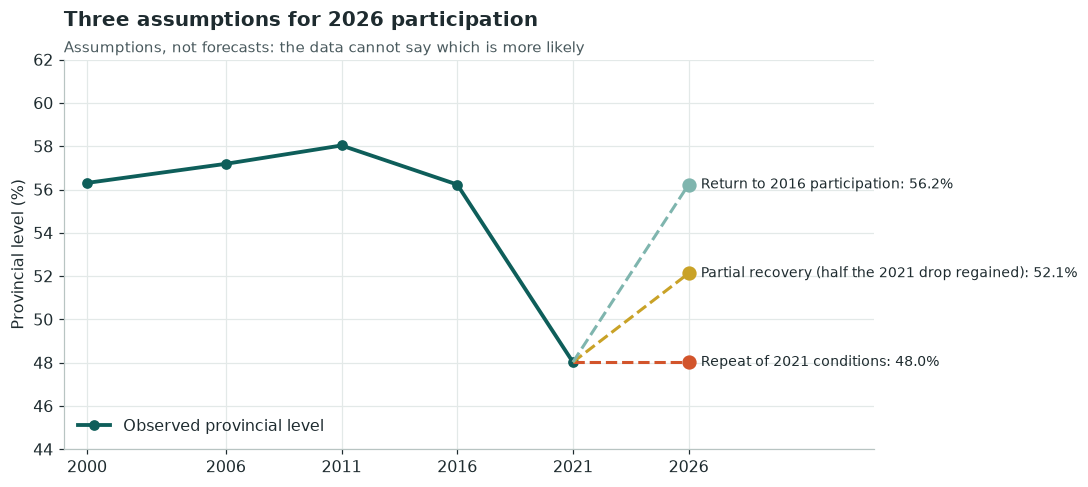

In [3]:
presets = S.turnout_level_presets(master)
display(pd.DataFrame({"Scenario": list(presets), "Assumed provincial level (%)": [round(v, 2) for v in presets.values()]}))

lv = master.groupby("Year")["ProvincialLevel_%"].first()
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(lv.index, lv.values, color=C.TEAL, marker="o", lw=2.5, label="Observed provincial level")
cols = [C.ALOE, "#C9A227", C.TEAL_LIGHT]
for (name, v), col in zip(presets.items(), cols):
    ax.plot([2021, 2026], [lv[2021], v], ls="--", color=col, lw=2)
    ax.scatter([2026], [v], color=col, s=70, zorder=3)
    ax.annotate(f"{name}: {v:.1f}%", (2026, v), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xticks(list(lv.index) + [2026]); ax.set_xlim(1999, 2034); ax.set_ylim(44, 62)
ax.set_ylabel("Provincial level (%)"); ax.legend(loc="lower left")
ax.set_title("Three assumptions for 2026 participation", pad=22)
subtitle(ax, "Assumptions, not forecasts: the data cannot say which is more likely")
save(fig, "turnout_level_scenarios", "phase6"); plt.show()

In [4]:
relative = S.project_relative_turnout(master, rel_selected)

reg_basis = "IEC 2026 registration snapshot"
if C.REGISTRATION_2026.exists():
    reg = pd.read_csv(C.REGISTRATION_2026).set_index("MuniCode")["RegisteredVoters"]
else:
    reg = master[master["Year"] == 2021].set_index("MuniCode")["RegisteredVoters"]
    reg_basis = "2021 registered voters (placeholder until the 2026 snapshot is added)"
print("Registered-voter basis:", reg_basis)

keys = {"Repeat of 2021 conditions": "Repeat2021",
        "Partial recovery (half the 2021 drop regained)": "PartialRecovery",
        "Return to 2016 participation": "Return2016"}
turnout_long = []
for name, level in presets.items():
    t = S.turnout_scenario(relative, level, BAND, registered=reg)
    t["Scenario"] = name; t["ScenarioKey"] = keys[name]
    turnout_long.append(t)
turnout_long = pd.concat(turnout_long, ignore_index=True)
turnout_long["Municipality"] = turnout_long["MuniCode"].map(C.muni_name)

agg = turnout_long.groupby("Scenario", sort=False).agg(MeanTurnout=("Turnout_%", "mean"),
                                                       ExpectedVotes=("ExpectedVotesCast", "sum"),
                                                       Registered=("RegisteredVoters", "sum"))
agg["WeightedTurnout_%"] = 100 * agg["ExpectedVotes"] / agg["Registered"]
display(agg.round(1))

Registered-voter basis: 2021 registered voters (placeholder until the 2026 snapshot is added)


,MeanTurnout,ExpectedVotes,Registered,WeightedTurnout_%
Scenario,,,,
Repeat of 2021 conditions,48.0,1.51e+06,3253307,46.4
Partial recovery (half the 2021 drop regained),52.1,1.64e+06,3253307,50.5
Return to 2016 participation,56.2,1.78e+06,3253307,54.6


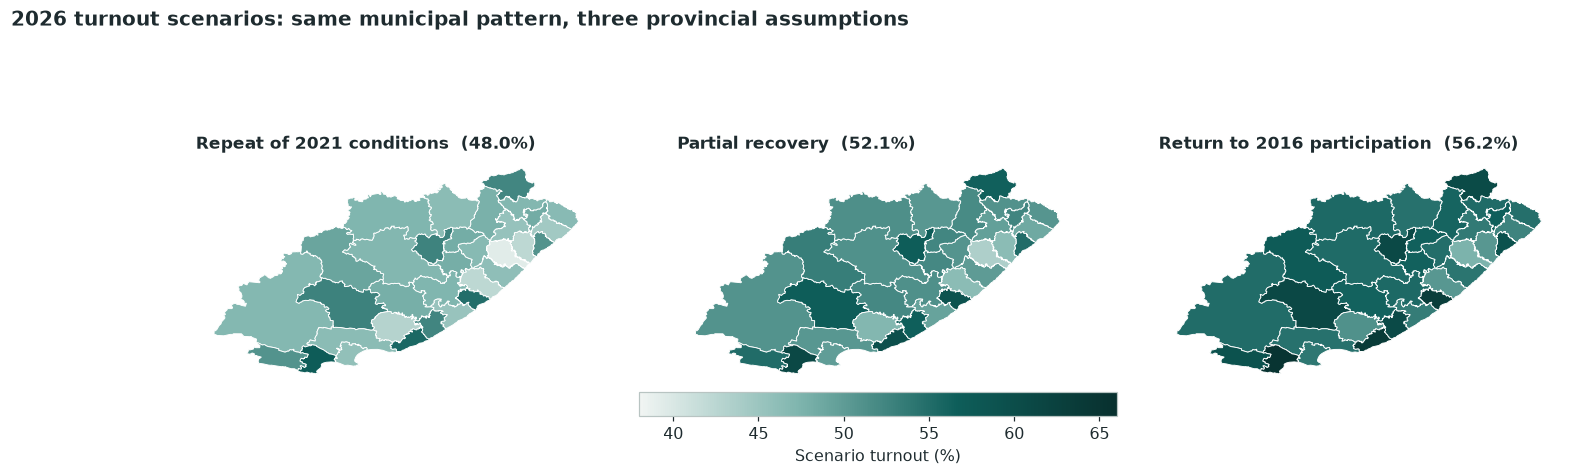

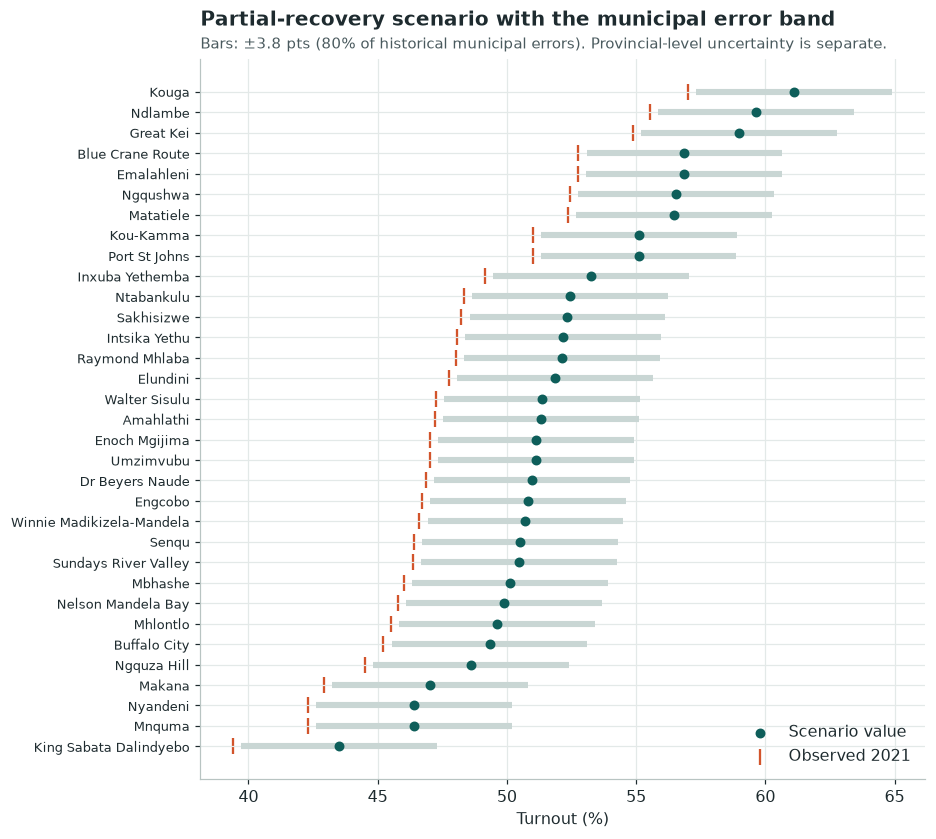

In [5]:
from src.data.geography import load_geojson
geo = load_geojson()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (name, key) in zip(axes, keys.items()):
    d = turnout_long[turnout_long["ScenarioKey"] == key]
    sm = choropleth(ax, geo, dict(zip(d["MuniCode"], d["Turnout_%"])), vmin=38, vmax=66)
    ax.set_title(f"{name.split(' (')[0]}  ({presets[name]:.1f}%)", fontsize=11)
fig.colorbar(sm, ax=axes, orientation="horizontal", shrink=.35, pad=.02, label="Scenario turnout (%)")
fig.suptitle("2026 turnout scenarios: same municipal pattern, three provincial assumptions",
             x=.02, ha="left", fontsize=13, fontweight="bold")
save(fig, "turnout_scenario_maps", "phase6"); plt.show()

d = turnout_long[turnout_long["ScenarioKey"] == "PartialRecovery"].sort_values("Turnout_%")
fig, ax = plt.subplots(figsize=(8.5, 8.5))
yy = np.arange(len(d))
ax.hlines(yy, d["Low_%"], d["High_%"], color="#C9D6D4", lw=4)
ax.scatter(d["Turnout_%"], yy, color=C.TEAL, s=30, zorder=3, label="Scenario value")
t21 = master[master["Year"] == 2021].set_index("MuniCode")["Turnout_%"]
ax.scatter(d["MuniCode"].map(t21), yy, marker="|", color=C.ALOE, s=120, label="Observed 2021")
ax.set_yticks(yy); ax.set_yticklabels(d["Municipality"], fontsize=8.5)
ax.set_xlabel("Turnout (%)"); ax.legend(loc="lower right")
ax.set_title("Partial-recovery scenario with the municipal error band", pad=22)
subtitle(ax, f"Bars: ±{BAND:.1f} pts (80% of historical municipal errors). Provincial-level uncertainty is separate.")
save(fig, "turnout_partial_recovery_bands", "phase6"); plt.show()

**Reading the maps.** The geography is identical in all three: Kouga, Ndlambe and the western municipalities stay above the provincial level and King Sabata Dalindyebo, Mnquma and Nyandeni below it, because relative positions persist. Only the overall level changes. The band around each municipality reflects how far historical municipal predictions missed; it does **not** include the uncertainty about which provincial level applies.

## 2. Party support under the validated methods

In [6]:
validated = S.project_party_shares(master, METHODS)
trend = S.last_swing_shares(master)
lead_val = S.leaders(validated, CLOSE)
lead_trend = S.leaders(trend, CLOSE)

valid21 = master[master["Year"] == 2021].set_index("MuniCode")["ValidVotes"]
def provincial(sh):
    w = sh["MuniCode"].map(valid21)
    return pd.Series({p: float((sh[p] * w).sum() / w.sum()) for p in C.PARTIES})
prov = pd.DataFrame({"2021 observed": provincial(master[master["Year"] == 2021][["MuniCode"] + C.PARTIES]),
                     "2026 validated (status quo)": provincial(validated),
                     "2026 alternative (trend continues)": provincial(trend)}).T
display(prov.round(2))
print("Largest category, validated:", lead_val["Leader"].value_counts().to_dict(),
      "| too close to call:", lead_val.loc[lead_val["TooCloseToCall"], "MuniCode"].map(C.muni_name).tolist())
print("Largest category, trend continues:", lead_trend["Leader"].value_counts().to_dict(),
      "| too close to call:", lead_trend.loc[lead_trend["TooCloseToCall"], "MuniCode"].map(C.muni_name).tolist())

,ANC,DA,EFF,UDM,ATM,OTHER
2021 observed,63.98,15.38,8.09,3.07,2.06,7.42
2026 validated (status quo),64.86,16.12,8.23,3.08,2.07,5.64
2026 alternative (trend continues),59.66,13.04,11.15,2.41,4.04,9.70


Largest category, validated: {'ANC': 31, 'DA': 2} | too close to call: ['Nelson Mandela Bay']
Largest category, trend continues: {'ANC': 31, 'DA': 2} | too close to call: ['Dr Beyers Naude', 'Nelson Mandela Bay']


**Interpretation.** Because validation mostly selected "no change", the validated 2026 composition is close to 2021, adjusted for the OTHER category; it is best read as a **status-quo baseline**. The *trend-continues* alternative repeats the 2016→2021 swing (ANC down about 4 points, EFF up about 3) and is shown because a judge or journalist will reasonably ask "what if the trend continues?", but it was **not** selected by validation. Neither accounts for parties founded after 2021, coalitions or the 2024 national election.

## 3. How close are the contests? Swing needed to change the largest party

Moving *x* points from the leader to the runner-up changes the gap by 2*x*, so the uniform swing needed to change the largest party is half the gap.

,Municipality,Leader,RunnerUp,LeaderShare_%,Gap_pts,SwingNeeded_pts,Status
32,Nelson Mandela Bay,DA,ANC,43.78,0.48,0.24,Too close to call
1,Dr Beyers Naude,ANC,DA,49.23,7.25,3.62,Clear lead under scenario
14,Inxuba Yethemba,ANC,DA,50.27,13.25,6.62,Clear lead under scenario
6,Kouga,DA,ANC,54.16,16.41,8.20,Clear lead under scenario
2,Blue Crane Route,ANC,DA,52.75,18.15,9.08,Clear lead under scenario
4,Ndlambe,ANC,DA,49.15,20.82,10.41,Clear lead under scenario
7,Kou-Kamma,ANC,DA,54.20,21.05,10.52,Clear lead under scenario
22,Walter Sisulu,ANC,DA,56.56,33.36,16.68,Clear lead under scenario


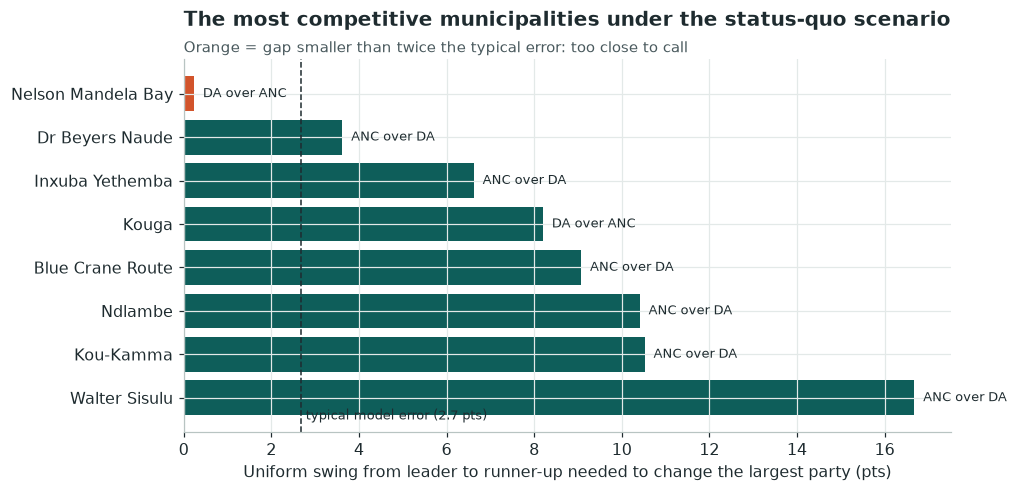

In [7]:
close = lead_val.copy()
close["Municipality"] = close["MuniCode"].map(C.muni_name)
close["SwingNeeded_pts"] = close["Gap_pts"] / 2
closest = close.sort_values("Gap_pts").head(8)
display(closest[["Municipality", "Leader", "RunnerUp", "LeaderShare_%", "Gap_pts", "SwingNeeded_pts", "Status"]].round(2))

fig, ax = plt.subplots(figsize=(9, 4.4))
yy = np.arange(len(closest))
ax.barh(yy, closest["SwingNeeded_pts"], color=[C.ALOE if t else C.TEAL for t in closest["TooCloseToCall"]])
for i, (_, r) in enumerate(closest.iterrows()):
    ax.text(r["SwingNeeded_pts"] + .2, i, f"{r['Leader']} over {r['RunnerUp']}", va="center", fontsize=8.5)
ax.axvline(PARTY_MAE, color=C.INK, ls="--", lw=1)
ax.text(PARTY_MAE + .1, len(closest) - .5, f"typical model error ({PARTY_MAE:.1f} pts)", fontsize=8.5)
ax.set_yticks(yy); ax.set_yticklabels(closest["Municipality"]); ax.invert_yaxis()
ax.set_xlabel("Uniform swing from leader to runner-up needed to change the largest party (pts)")
ax.set_title("The most competitive municipalities under the status-quo scenario", pad=22)
subtitle(ax, "Orange = gap smaller than twice the typical error: too close to call")
save(fig, "swing_needed", "phase6"); plt.show()

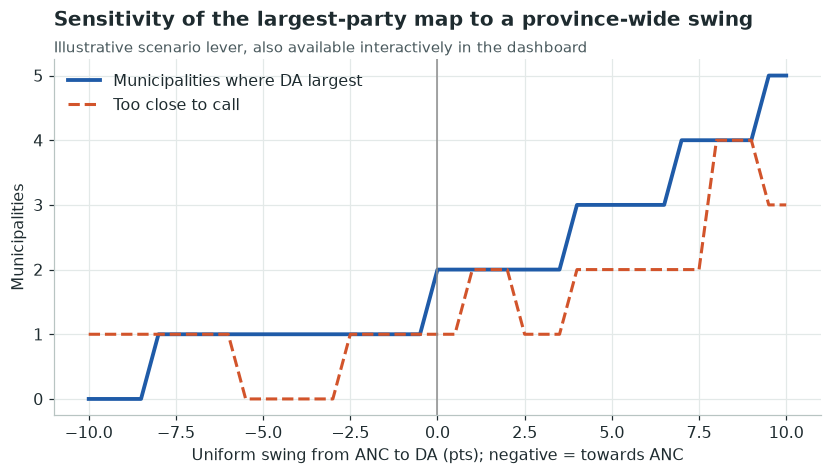

,ANC_to_DA_swing_pts,ANC_leads,DA_leads,TooClose
10,-5.0,32,1,0
20,0.0,31,2,1
24,2.0,31,2,2
30,5.0,30,3,2
40,10.0,28,5,3


In [8]:
# Sensitivity: how many municipalities change largest party under a uniform ANC -> DA swing?
rows = []
for s in np.arange(-10, 10.5, 0.5):
    sh = S.apply_swing(validated, {"ANC": -s, "DA": s})
    L = S.leaders(sh, CLOSE)
    rows.append({"ANC_to_DA_swing_pts": s, "ANC_leads": int((L["Leader"] == "ANC").sum()),
                 "DA_leads": int((L["Leader"] == "DA").sum()), "TooClose": int(L["TooCloseToCall"].sum())})
sens = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(sens["ANC_to_DA_swing_pts"], sens["DA_leads"], color=C.PARTY_COLORS["DA"], lw=2.5, label="Municipalities where DA largest")
ax.plot(sens["ANC_to_DA_swing_pts"], sens["TooClose"], color=C.ALOE, lw=2, ls="--", label="Too close to call")
ax.axvline(0, color=C.GREY, lw=1)
ax.set_xlabel("Uniform swing from ANC to DA (pts); negative = towards ANC"); ax.set_ylabel("Municipalities")
ax.legend(); ax.set_title("Sensitivity of the largest-party map to a province-wide swing", pad=22)
subtitle(ax, "Illustrative scenario lever, also available interactively in the dashboard")
save(fig, "swing_sensitivity", "phase6"); plt.show()
display(sens[sens["ANC_to_DA_swing_pts"].isin([-5, 0, 2, 5, 10])])

## 4. Assemble, check and save

In [9]:
wide = relative[["MuniCode", "PreviousRelative_pts", "PreviousTurnout_%", "RelativeTurnout_2026"]].rename(
    columns={"PreviousRelative_pts": "Relative_2021_pts", "PreviousTurnout_%": "Turnout_2021_%", "RelativeTurnout_2026": "Relative_2026_pts"})
wide["Municipality"] = wide["MuniCode"].map(C.muni_name); wide["District"] = wide["MuniCode"].map(C.DISTRICTS)
for key in keys.values():
    t = turnout_long[turnout_long["ScenarioKey"] == key].set_index("MuniCode")
    wide[f"Turnout_{key}_%"] = wide["MuniCode"].map(t["Turnout_%"])
    wide[f"ExpectedVotes_{key}"] = wide["MuniCode"].map(t["ExpectedVotesCast"])
wide["TurnoutBand_pts"] = BAND
wide["RegisteredVoters"] = wide["MuniCode"].map(reg); wide["RegistrationBasis"] = reg_basis
v = validated.set_index("MuniCode"); tr = trend.set_index("MuniCode")
for p in C.PARTIES:
    wide[f"{p}_2021_%"] = wide["MuniCode"].map(master[master["Year"] == 2021].set_index("MuniCode")[p])
    wide[f"{p}_Validated_%"] = wide["MuniCode"].map(v[p])
    wide[f"{p}_Trend_%"] = wide["MuniCode"].map(tr[p])
    wide[f"{p}_Method"] = METHODS[p]
wide["PartyBand_pts"] = PARTY_MAE
lv_ = lead_val.set_index("MuniCode")
for col in ["Leader", "RunnerUp", "Gap_pts", "Status"]:
    wide[f"Validated_{col}"] = wide["MuniCode"].map(lv_[col])
wide["Trend_Leader"] = wide["MuniCode"].map(lead_trend.set_index("MuniCode")["Leader"])
wide["SwingNeeded_pts"] = wide["Validated_Gap_pts"] / 2

party_long_out = pd.concat([validated.assign(Scenario="Validated status quo"), trend.assign(Scenario="Trend continues (not validated)")])
qc = pd.DataFrame([
    ("Municipalities", wide["MuniCode"].nunique(), 33),
    ("Turnout outside 0-100", int((~turnout_long["Turnout_%"].between(0, 100)).sum()), 0),
    ("Validated shares not summing to 100", int((~np.isclose(validated[C.PARTIES].sum(axis=1), 100)).sum()), 0),
    ("Trend shares not summing to 100", int((~np.isclose(trend[C.PARTIES].sum(axis=1), 100)).sum()), 0),
    ("Negative shares", int((party_long_out[C.PARTIES] < 0).sum().sum()), 0),
    ("Repeat-2021 turnout differs from observed 2021 (persistence check)",
     int((~np.isclose(wide["Turnout_Repeat2021_%"], wide["Turnout_2021_%"])).sum()), 0),
], columns=["Check", "Actual", "Expected"])
qc["Pass"] = qc["Actual"] == qc["Expected"]
display(qc); assert qc["Pass"].all(), "Phase 6 QC failed"

methodology = pd.DataFrame([
    ["Nature of outputs", "Model-based scenarios, not forecasts or known results"],
    ["Turnout", f"Assumed provincial level + municipal relative position ({rel_selected})"],
    ["Turnout levels", "; ".join(f"{k}: {v:.2f}%" for k, v in presets.items())],
    ["Turnout band", f"±{BAND:.2f} pts = 80th percentile of historical absolute municipal errors (excludes level uncertainty)"],
    ["Party support", "; ".join(f"{k}: {v}" for k, v in METHODS.items()) + "; refit on all transitions 2006-2021"],
    ["Party alternative", "Trend continues: repeat 2016->2021 mean swing per party (not validated)"],
    ["Too close to call", f"Lead < 2 x 2021 test MAE ({CLOSE:.2f} pts)"],
    ["Registered voters", reg_basis],
    ["Not modelled", "Parties founded after 2021, coalitions, candidates, campaigns, 2024 NPE results"],
], columns=["Item", "Value"])
summary = pd.DataFrame([
    ["Scenario turnout, repeat of 2021 (mean municipal %)", presets["Repeat of 2021 conditions"]],
    ["Scenario turnout, partial recovery (mean municipal %)", presets["Partial recovery (half the 2021 drop regained)"]],
    ["Scenario turnout, return to 2016 (mean municipal %)", presets["Return to 2016 participation"]],
    ["Municipal turnout band (pts)", BAND],
    ["Municipalities with ANC largest (validated)", int((lead_val["Leader"] == "ANC").sum())],
    ["Municipalities with DA largest (validated)", int((lead_val["Leader"] == "DA").sum())],
    ["Too close to call (validated)", int(lead_val["TooCloseToCall"].sum())],
    ["Party share typical error (pts)", PARTY_MAE],
], columns=["Measure", "Value"])
out = C.DIRS["phase6"]
files = {"municipality_scenarios_2026.csv": wide, "turnout_scenarios_2026.csv": turnout_long,
         "party_scenarios_2026.csv": party_long_out, "swing_sensitivity_2026.csv": sens,
         "scenario_summary_2026.csv": summary, "phase6_methodology.csv": methodology, "phase6_quality_control.csv": qc}
for name, df in files.items():
    df.to_csv(out / name, index=False); print(f"Saved {name:36s} {len(df):4d} rows")

,Check,Actual,Expected,Pass
0,Municipalities,33,33,True
1,Turnout outside 0-100,0,0,True
2,Validated shares not summing to 100,0,0,True
3,Trend shares not summing to 100,0,0,True
4,Negative shares,0,0,True
5,Repeat-2021 turnout differs from observed 2021...,0,0,True


Saved municipality_scenarios_2026.csv        33 rows
Saved turnout_scenarios_2026.csv             99 rows
Saved party_scenarios_2026.csv               66 rows
Saved swing_sensitivity_2026.csv             41 rows
Saved scenario_summary_2026.csv               8 rows
Saved phase6_methodology.csv                  9 rows
Saved phase6_quality_control.csv              6 rows


## What can and cannot be claimed

**Can be said**
- "Under a partial-recovery assumption, Kouga's scenario turnout is about X%, within roughly ±3.8 points of municipal error."
- "Relative turnout positions have been stable since 2011, so municipalities with low turnout in 2021 are likely to remain below the provincial level."
- "Nelson Mandela Bay's largest-party outcome is too close to call on historical patterns."

**Should not be said**
- That any scenario value *is* the 2026 result, or that one turnout level is the expected one.
- That bands are confidence intervals (they are empirical error scales).
- That demographics *cause* turnout or party support, or describe individual voters.
- That the model accounts for new parties, coalitions or events since 2021.

## Pipeline complete

Historical elections → demographics → master panel and analysis → validated turnout model → validated party model → 2026 scenarios. The Streamlit dashboard (`app/app.py`) reads these outputs and uses `src/models/scenarios.py` for its interactive scenario explorer.

## References

Citations were compiled by the team; verify page/URL details before final submission.

- Electoral Commission of South Africa (IEC). Municipal (Local Government) Election results, detailed downloads 2000, 2006, 2011, 2016, 2021. https://results.elections.org.za/home/downloads/me-results
- IEC. Voter Registration Statistics (dashboard). https://www.elections.org.za/pw/StatsData/Voter-Registration-Statistics
- Statistics South Africa. Census 2011 and Census 2022 (https://census.statssa.gov.za). Note: the upstream tables behind data/processed/demographics/clean_census.csv are not recorded in the repository; see docs/DATA_SOURCES.md.
- Hyndman, R.J. & Athanasopoulos, G. (2021). Forecasting: Principles and Practice, 3rd ed., ch. 5.10 (time-series cross-validation). https://otexts.com/fpp3/
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. JMLR 12, 2825-2830.

In [10]:
# Software used in this notebook (versions recorded for reproducibility)
import platform
from importlib.metadata import version, PackageNotFoundError
rows = [("python", platform.python_version())]
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'statsmodels', 'shapely', 'xlrd', 'nbformat']:
    try:
        rows.append((pkg, version(pkg)))
    except PackageNotFoundError:
        rows.append((pkg, "not installed"))
display(pd.DataFrame(rows, columns=["Package", "Version"]))

,Package,Version
0,python,3.13.15
1,pandas,3.0.6
2,numpy,2.5.3
3,matplotlib,3.11.2
4,scikit-learn,1.9.1
5,statsmodels,0.15.0
6,shapely,2.1.2
7,xlrd,2.0.2
8,nbformat,5.11.1
